In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_images(images, titles, figsize=(15, 5)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i + 1)
        if len(images[i].shape) == 2:
            plt.imshow(images[i], cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis('off')
    plt.show()

Откройте изображение Morph.jpg. Примените к немубазовыеморфологические операции (дилатацию и эрозию) с структурнымиэлементами крест, прямоугольник и эллипс (для каждого из нихпопробуйтеразмеры 3x3 и 5х5) и с 1, 3 , 5 итерациями.

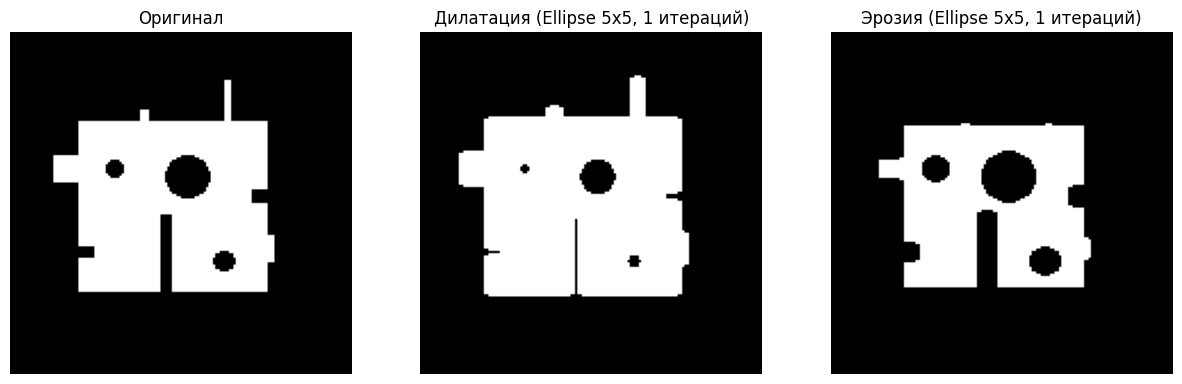

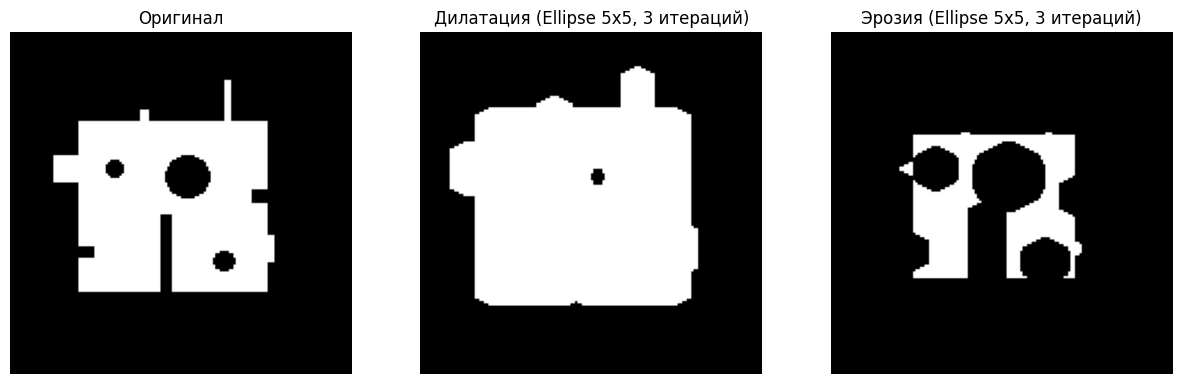

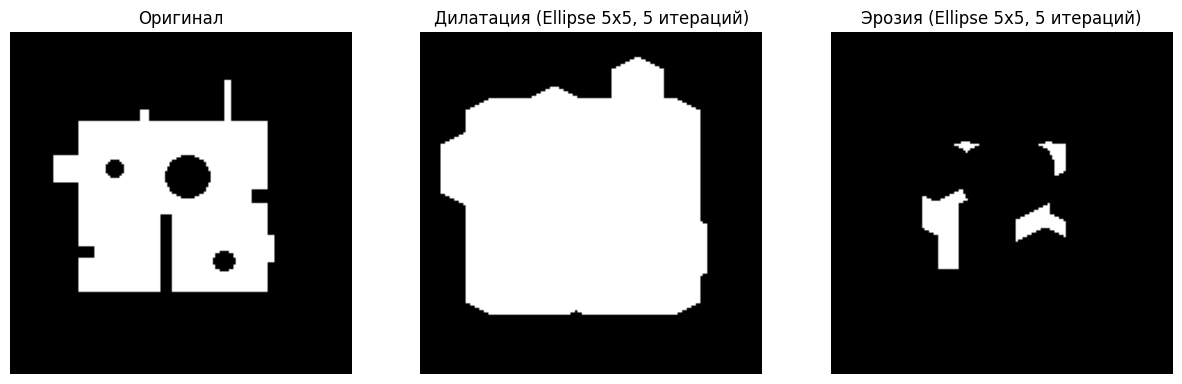

In [2]:
#Задание 1

img_morph = cv2.imread('Morph.jpg', cv2.IMREAD_GRAYSCALE)
_, img_morph_bin = cv2.threshold(img_morph, 127, 255, cv2.THRESH_BINARY)

kernels = {
    'Cross 3x3': cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3)),
    'Cross 5x5': cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5)),
    'Rect 3x3': cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)),
    'Rect 5x5': cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5)),
    'Ellipse 3x3': cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3)),
    'Ellipse 5x5': cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
}

iterations_list = [1, 3, 5]

kernel_name = 'Ellipse 5x5'
kernel = kernels[kernel_name]

for iters in iterations_list:
    #дилатацию. расширяет объект
    dilated = cv2.dilate(img_morph_bin, kernel, iterations=iters)
    #эрозию. сжимает объект
    eroded = cv2.erode(img_morph_bin, kernel, iterations=iters)

    show_images(
        [img_morph_bin, dilated, eroded],
        ['Оригинал', f'Дилатация ({kernel_name}, {iters} итераций)', f'Эрозия ({kernel_name}, {iters} итераций)']
    )

Дилатация расширяет объекты, делая их толще и закрывая мелкие черные дыры. Эрозия, наоборот, сжимает объекты, истончая линии и удаляя мелкий белый шум. Использование эллипса делает углы более округлыми, в то время как прямоугольник сохраняет их блочными. Увеличение количества итераций или размера ядра усиливает этот эффект.

2. Попробуйте сравнить результаты операций открытия изакрытиясрезультатами последовательного применения


3. Попробуйте сравнить результаты операции закрытия с результатамипоследовательного применения дилатации и эрозии:
close(A,B) =er(dil(A,B),B)


4. Попробуйте сравнить результаты операции открытия с результатамипоследовательного применения эрозии и дилатации:
open(A,B) =dil(er(A,B),B)

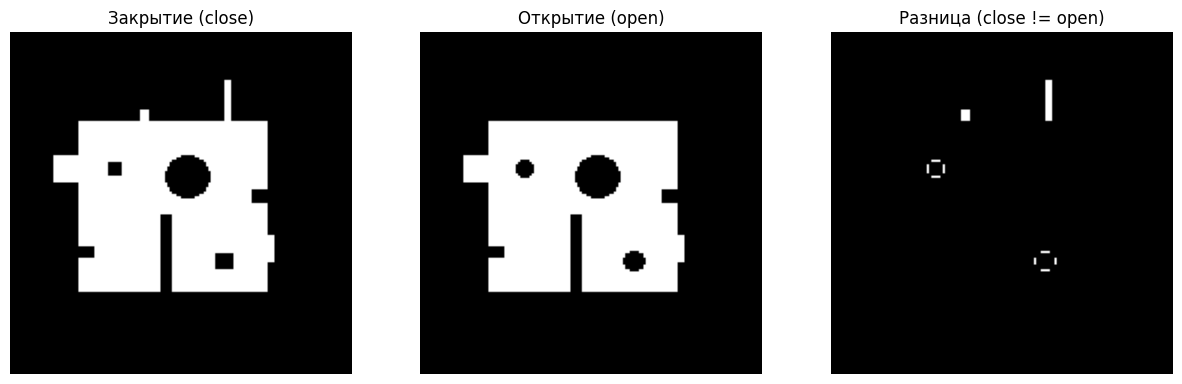

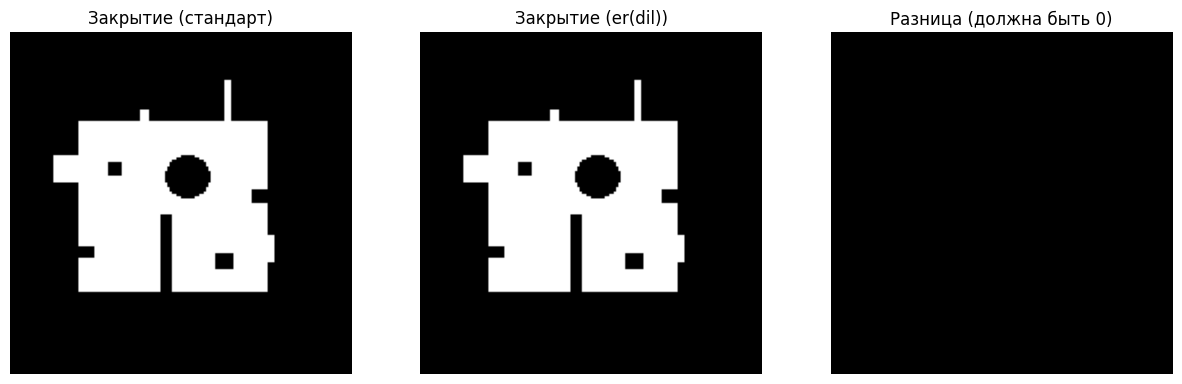

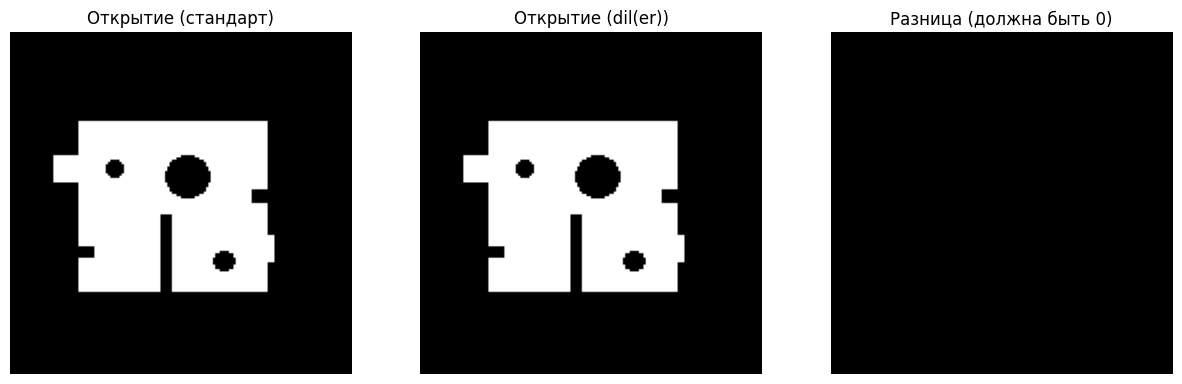

In [8]:
#Задание 2: Сравнение открытия и закрытия
#Доказательство: close(A,B) != open(A,B)

kernel = kernels['Rect 5x5']

# Получаем результаты операций
close_result = cv2.morphologyEx(img_morph_bin, cv2.MORPH_CLOSE, kernel)
open_result = cv2.morphologyEx(img_morph_bin, cv2.MORPH_OPEN, kernel)

# Сравниваем результаты
diff_close_open = cv2.absdiff(close_result, open_result)

show_images(
    [close_result, open_result, diff_close_open],
    ['Закрытие (close)', 'Открытие (open)', 'Разница (close != open)']
)


#Задание 3: Проверка определения закрытия
#Доказательство: close(A,B) = er(dil(A,B),B)

# Стандартное закрытие
close_std = cv2.morphologyEx(img_morph_bin, cv2.MORPH_CLOSE, kernel)

# Ручное закрытие: дилатация + эрозия
dilated = cv2.dilate(img_morph_bin, kernel, iterations=1)
close_manual = cv2.erode(dilated, kernel, iterations=1)

# Сравниваем результаты
diff_close = cv2.absdiff(close_std, close_manual)

# Вывод для задания 3
show_images(
    [close_std, close_manual, diff_close],
    ['Закрытие (стандарт)', 'Закрытие (er(dil))', 'Разница (должна быть 0)']
)



#Задание 4: Проверка определения открытия
#Доказательство: open(A,B) = dil(er(A,B),B)

# Стандартное открытие
open_std = cv2.morphologyEx(img_morph_bin, cv2.MORPH_OPEN, kernel)

# Ручное открытие: эрозия + дилатация
eroded = cv2.erode(img_morph_bin, kernel, iterations=1)
open_manual = cv2.dilate(eroded, kernel, iterations=1)

# Сравниваем результаты
diff_open = cv2.absdiff(open_std, open_manual)

# Вывод для задания 4
show_images(
    [open_std, open_manual, diff_open],
    ['Открытие (стандарт)', 'Открытие (dil(er))', 'Разница (должна быть 0)']
)

Вывод: Эксперимент подтверждает теоретическую справку: изображения идентичны, разница равна нулю.

Задание 5. Для всех изображений найдите границы, используя определение:
boundary(A,B) = A – er(A,B)
Поэкспериментируйте со структурными элементами и их размерами.

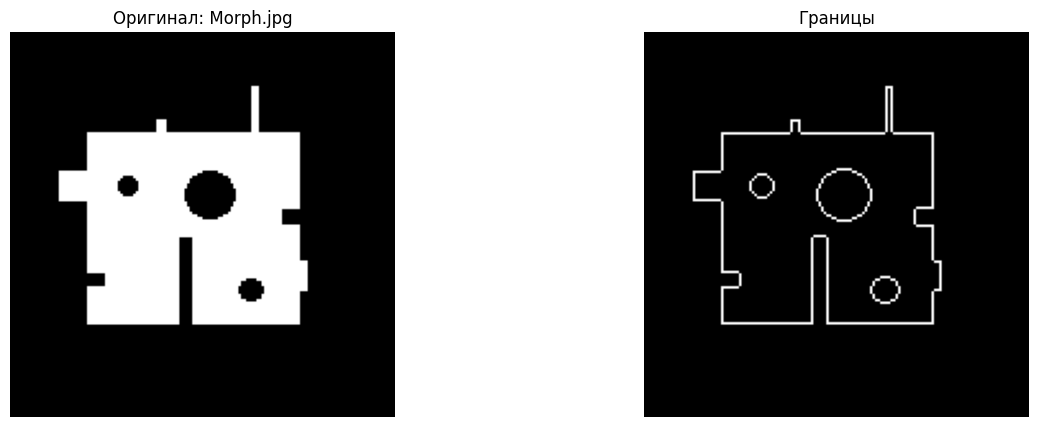

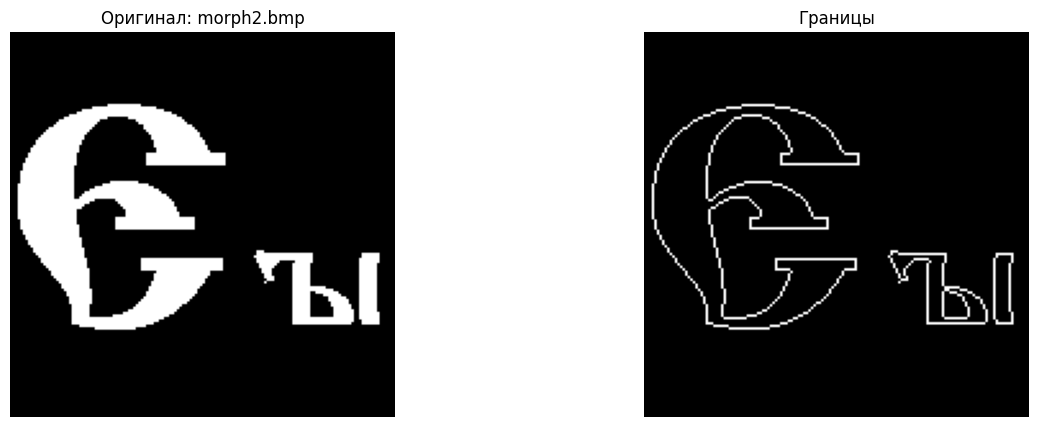

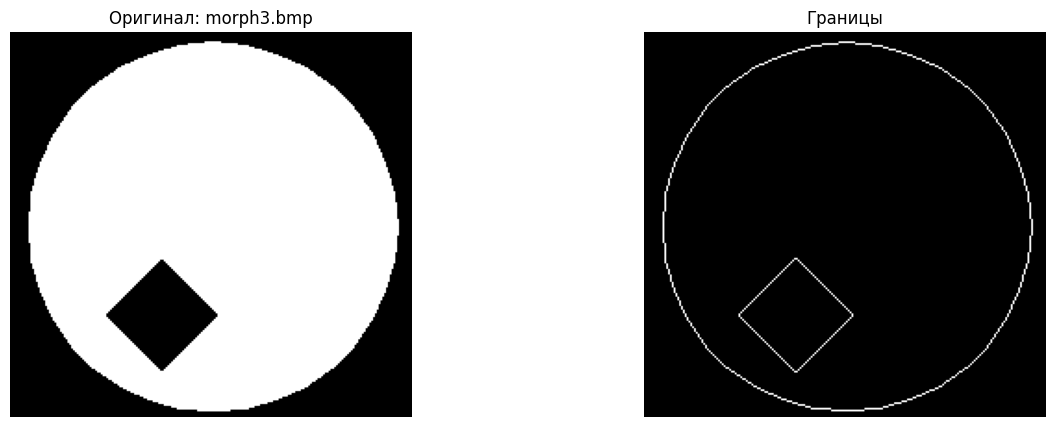

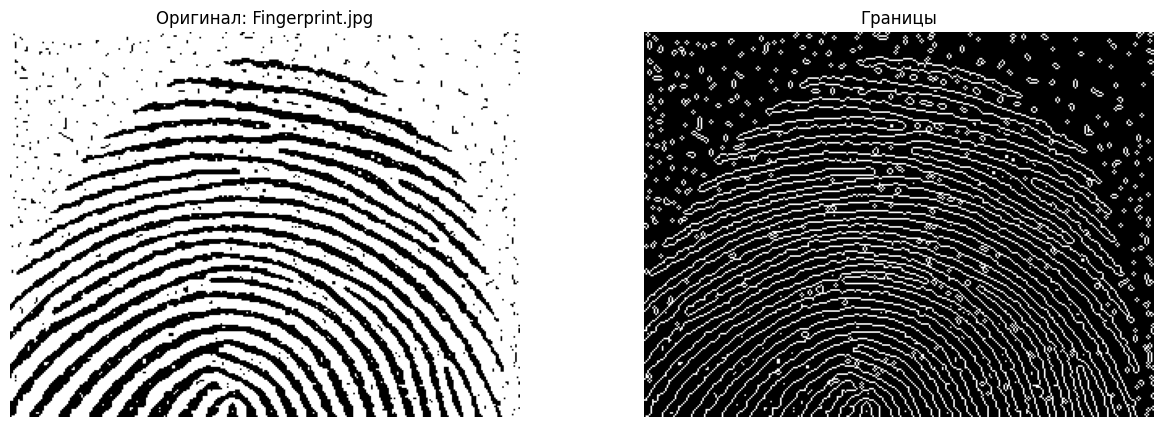

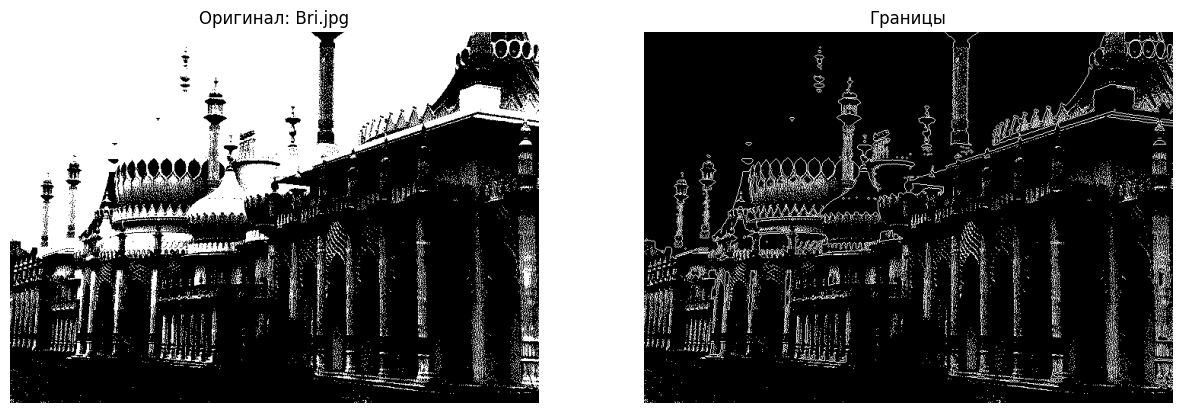

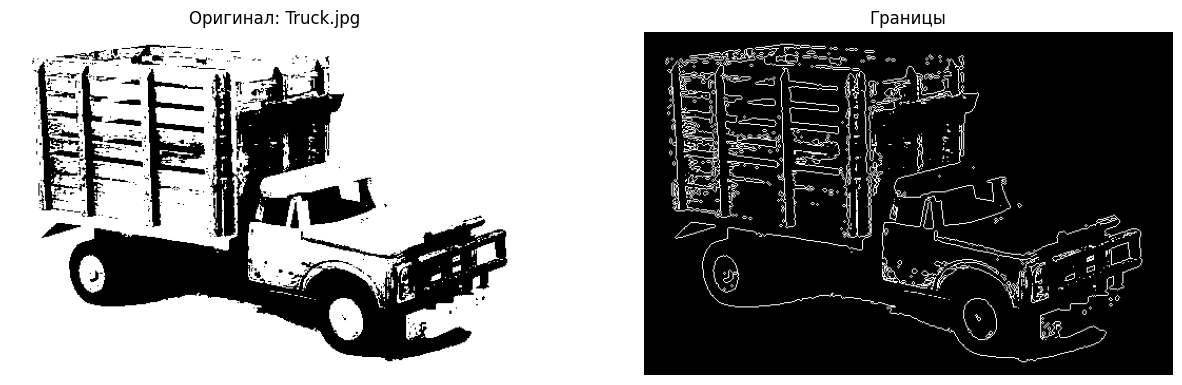

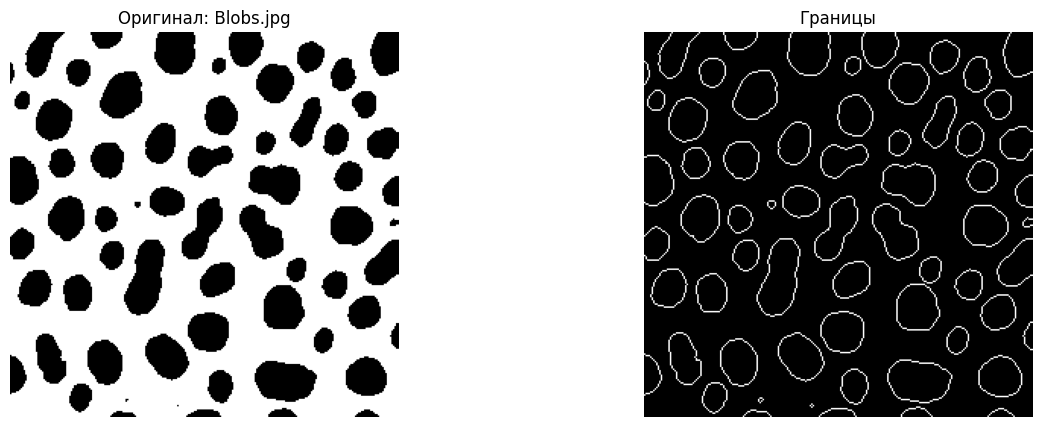

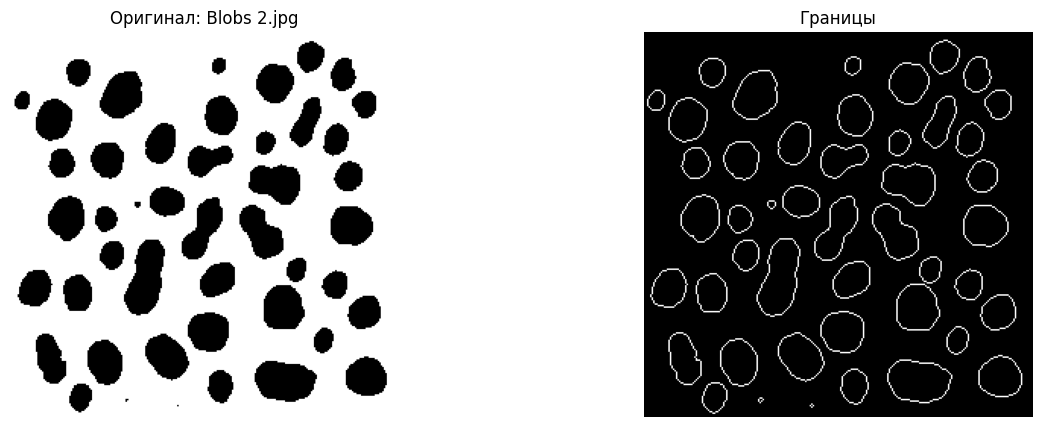

In [4]:
#Задание 5. Поиск границ для всех предоставленных изображений

image_files = ['Morph.jpg', 'morph2.bmp', 'morph3.bmp', 'Fingerprint.jpg',
               'Bri.jpg', 'Truck.jpg', 'Blobs.jpg', 'Blobs 2.jpg']

boundary_kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))

for file_name in image_files:
    img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        _, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

        #эрозия
        eroded_img = cv2.erode(img_bin, boundary_kernel, iterations=1)

        #Вычисляем границу. Вычитаем эродированное изображение из оригинала
        boundary = cv2.subtract(img_bin, eroded_img)

        show_images([img_bin, boundary], [f'Оригинал: {file_name}', 'Границы'])

Предпочтительный структурный элемент: Крест 3х3 (MORPH_CROSS). Он оптимален, так как захватывает только непосредственных 4-соседей пикселя, что позволяет получить границу толщиной ровно в один пиксель. Эллипс или большие размеры (5x5) дают слишком «жирные» и размытые контуры.

6. Подберите структурный элемент, который бы наилучшимобразомсглаживал углы на изображениях morph.bmp и morph2.bmp. Какуюизопераций Вы использовали при этом и почему?

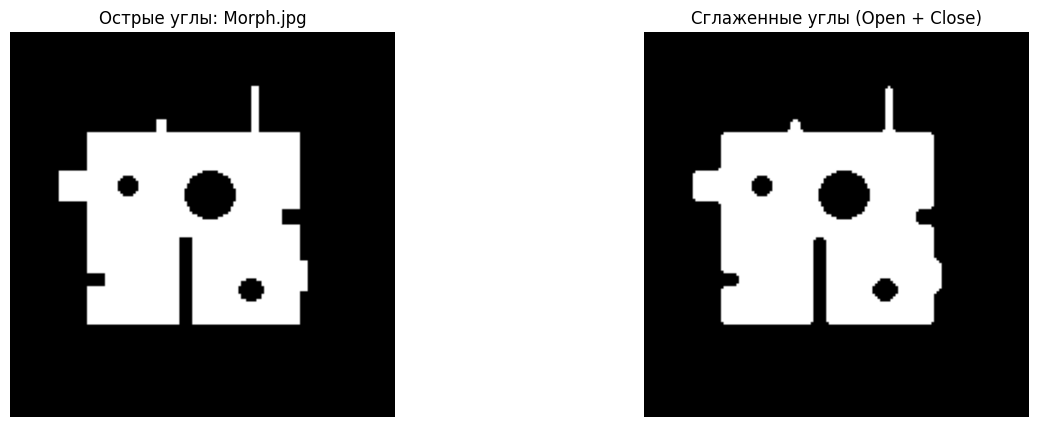

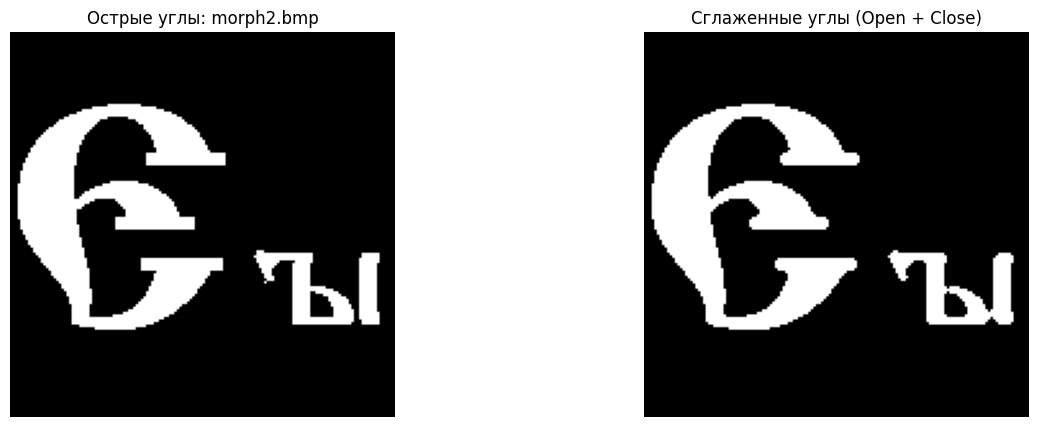

In [5]:
#Задание 6. Сглаживание углов

images_to_smooth = ['Morph.jpg', 'morph2.bmp']
#Выбрал эллипс, потому что именно он лучше всего подходит для округления углов
smooth_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))

for file_name in images_to_smooth:
    img = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)
    _, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)


    smoothed = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, smooth_kernel)

    smoothed = cv2.morphologyEx(smoothed, cv2.MORPH_CLOSE, smooth_kernel)

    show_images([img_bin, smoothed], [f'Острые углы: {file_name}', 'Сглаженные углы (Open + Close)'])

Используемые операции: Я использовал последовательность Открытия и Закрытия. Открытие сглаживает контуры и ликвидирует острые выступы , а закрытие сглаживает впадины и заполняет небольшие разрывы. Структурный элемент «эллипс» идеально подходит для придания углам круглой формы.

7. С помощью порога бинаризуйте изображение morph3.bmp. Найдитеконтуры каждого элемента по отдельности, (используйте дляэтогоразноезначение порога). Выделите несколько объектов на изображении, найдитеихконтуры. Опишите и сохраните результаты. Какие фильтрыВывыбирали?

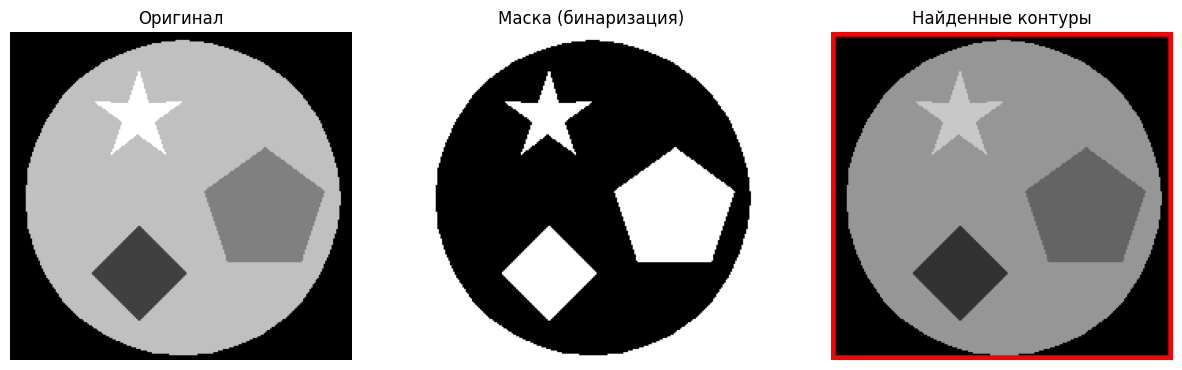

Я нашла 1 объекта(ов) на изображении morph3.bmp.


In [ ]:
#Задание 7. Бинаризация morph3.bmp и поиск контуров

img_morph3 = cv2.imread('morph3.bmp', cv2.IMREAD_GRAYSCALE)
img_color = cv2.cvtColor(img_morph3, cv2.COLOR_GRAY2BGR) # Копия для отрисовки цветных контуров

#Сначала я применяю бинаризацию по порогу
_, thresh1 = cv2.threshold(img_morph3, 100, 255, cv2.THRESH_BINARY_INV) #Выделяет темные фигуры (пятиугольник, ромб)
_, thresh2 = cv2.threshold(img_morph3, 150, 255, cv2.THRESH_BINARY)     #Выделяет светлую звезду

#объединяю обе маски с помощью логического ИЛИ
combined_mask = cv2.bitwise_or(thresh1, thresh2)

contours, hierarchy = cv2.findContours(combined_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#Отрисовываю найденные контуры красным цветом
cv2.drawContours(img_color, contours, -1, (0, 0, 255), 3)

show_images([img_morph3, combined_mask, img_color],
            ['Оригинал', 'Маска (бинаризация)', 'Найденные контуры'])

print(f"Я нашёл {len(contours)} объекта(ов) на изображении morph3.bmp.")

8. Откройте изображение Fingerprint.jpg. Разработайте иреализуйтепоследовательность морфологических операций для качественноговыделения отпечатка пальца из изображения.

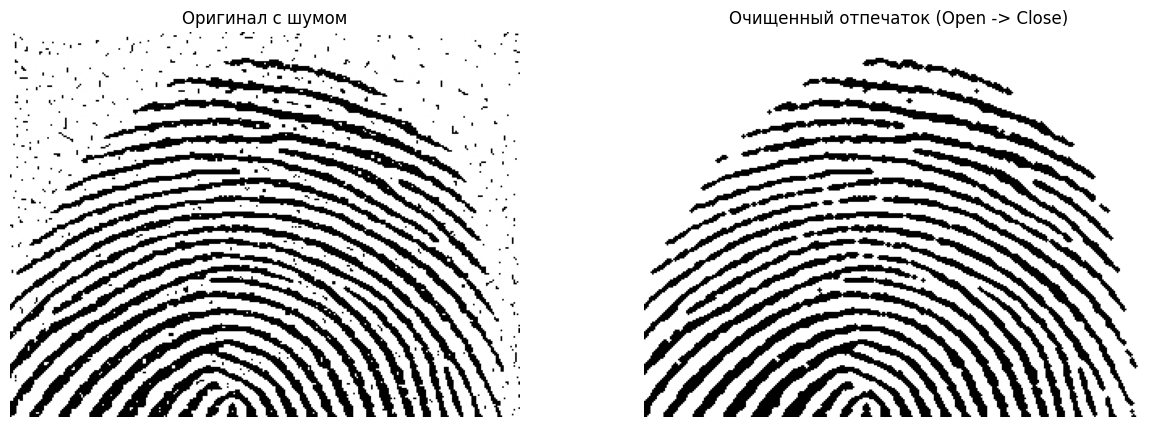

In [7]:
#Задание 8. Качественное выделение отпечатка пальца

img_finger = cv2.imread('Fingerprint.jpg', cv2.IMREAD_GRAYSCALE)

#Бинаризую изображение
_, img_finger_bin = cv2.threshold(img_finger, 127, 255, cv2.THRESH_BINARY_INV)

kernel_small = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))


step1_open = cv2.morphologyEx(img_finger_bin, cv2.MORPH_OPEN, kernel_small)


step2_close = cv2.morphologyEx(step1_open, cv2.MORPH_CLOSE, kernel_small)

final_fingerprint = cv2.bitwise_not(step2_close)

show_images([img_finger, final_fingerprint],
            ['Оригинал с шумом', 'Очищенный отпечаток (Open -> Close)'])